## Interprétation des coefficients du classifieur

Le classifieur utilisé est une **régression logistique** implémentée via `sklearn.linear_model.LogisticRegression`. Il a été entraîné sur l'ensemble `similarity_dataset.csv` contenant 3435 paires de phrases annotées selon trois classes : `parallèle`, `semi-parallèle` et `non-parallèle`. Les données sont divisées en un jeu d'entraînement (80 %) et un jeu de test (20 %) avec stratification, puis normalisées via un `StandardScaler`. Cette normalisation est essentielle car les coefficients de régression logistique sont sensibles à l'échelle des variables : sans mise à l'échelle, une feature avec une grande amplitude dominerait artificiellement les autres.

L'entraînement proprement dit a été réalisé avec un paramètre de régularisation $C = 1.0$ (inverse de la force de régularisation L2) et un maximum de 1000 itérations. Deux modèles ont été sauvegardés : un **modèle binaire** (non-parallèle vs parallèle/semi-parallèle) et un **modèle multiclasse** (3 classes). Les modèles rechargés ici (`joblib.load`) permettent d'extraire les coefficients appris.

Chaque coefficient $w_j$ d'une feature $x_j$ agit sur le **log-odds** (logarithme du rapport de cotes) selon la relation fondamentale de la régression logistique :

$$
\log\left(\frac{P(y=1 \mid \mathbf{x})}{1 - P(y=1 \mid \mathbf{x})}\right) = w_0 + w_1 x_1 + w_2 x_2 + \cdots + w_6 x_6
$$

Un coefficient **positif** signifie qu'une augmentation de la feature accroît la probabilité d'appartenir à la classe positive (parallèle/semi-parallèle). Un coefficient **négatif** indique l'effet inverse. L'**odds ratio** $e^{w_j}$ se calcule en appliquant l'exponentielle au coefficient : il représente le facteur multiplicatif des *odds* (rapport de probabilité d'appartenir à la classe positive vs négative) lorsqu'on augmente la feature $x_j$ d'une unité. Comme les données ont été normalisées par `StandardScaler`, cette "unité" correspond à **un écart-type** de la feature. Par exemple, un odds ratio de 4 signifie qu'une augmentation d'un écart-type de la feature multiplie les chances d'être dans la classe positive par 4. L'odds ratio est plus intuitif que le coefficient brut pour communiquer l'ampleur de l'effet d'une feature.

Le tableau ci-dessous présente les coefficients et les odds ratios pour le modèle binaire, suivis des coefficients et odds ratios par classe pour le modèle multiclasse. Les graphiques associés visualisent ces coefficients par feature.



---


## Imports et configuration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import unicodedata
import string
import re
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    average_precision_score,
)
from sklearn.pipeline import Pipeline

# -------------------------------------------------------
# Configuration
# -------------------------------------------------------
DATASET_PATH   = "../data/similarity_dataset.csv"
MODEL_BIN_PATH   = "../data/models/logreg_binary.joblib"
MODEL_MC_PATH    = "../data/models/logreg_multiclass.joblib"
SCALER_PATH      = "../data/models/scaler.joblib"
RANDOM_STATE   = 42
TEST_SIZE      = 0.2

FEATURE_COLS = [
    "sbert_score",
    "length_score",
    "jaccard_bigrams",
    "jaccard_trigrams",
    "jaccard_quadrigrams",
    "phonetic_jaccard",
]

In [2]:
# -------------------------------------------------------
# Chargement des modèles pré-entraînés
# -------------------------------------------------------
import joblib

BASE_DIR = "../data/models/"
DATASET_PATH   = "../data/similarity_dataset.csv"
MODEL_BIN_PATH   = BASE_DIR + "logreg_binary.joblib"
MODEL_MC_PATH    = BASE_DIR + "logreg_multiclass.joblib"
SCALER_PATH      = BASE_DIR + "scaler.joblib"

print(f"Chargement des modèles depuis {BASE_DIR}...")
scaler       = joblib.load(SCALER_PATH)
logreg_bin   = joblib.load(MODEL_BIN_PATH)
logreg_mc    = joblib.load(MODEL_MC_PATH)
print("Modèles chargés avec succès.")
print(f"  - Modèle binaire : {MODEL_BIN_PATH}")
print(f"  - Modèle multiclasse : {MODEL_MC_PATH}")
print(f"  - Scaler : {SCALER_PATH}")


Chargement des modèles depuis ../data/models/...
Modèles chargés avec succès.
  - Modèle binaire : ../data/models/logreg_binary.joblib
  - Modèle multiclasse : ../data/models/logreg_multiclass.joblib
  - Scaler : ../data/models/scaler.joblib




---


## Chargement et exploration des données

In [3]:
df = pd.read_csv(DATASET_PATH, encoding="utf-8-sig")
df.head(3)

,fr_sentence,lr_sentence,language_pair,class,binary_class,sbert_score,length_score,jaccard_bigrams,jaccard_trigrams,jaccard_quadrigrams,phonetic_jaccard
0,Article 10,Articulu,fr-co,semi-parallel,1,0.827877,0.500000,0.333333,0.272727,0.200000,1.000000
1,"La bise et le soleil se disputaient, chacun as...",Lo sorelh e la bisa se capinhavan,fr-oc,semi-parallel,1,0.370990,0.730769,0.207921,0.061644,0.030864,0.111111
2,Ils sont tombés d'accord que celui qui arriver...,Se son acordats qu'aquèlo que capitariá lo pro...,fr-oc,parallel,1,0.372616,0.130435,0.446602,0.148571,0.069307,0.233333


In [4]:
print("=== Distribution des classes ===")
print(df["class"].value_counts().to_string())

print("\n=== Distribution par langue ===")
# Regroupe les variétés dialectales en 3 grandes langues régionales
# La colonne language_pair contient des valeurs comme "fr-gsw", "fr-co", "fr-oc", etc.
def extract_lang(lang_pair):
    parts = lang_pair.split("-")
    if len(parts) >= 2:
        lang = parts[-1]
    else:
        lang = lang_pair
    regional_map = {
        "co":  "Corse",
        "gsw": "Alsacien",
        "oc":  "Occitan",
    }
    if lang in regional_map:
        return regional_map[lang]
    return "Autre"

df["langue_groupe"] = df["language_pair"].apply(extract_lang)
print(df["langue_groupe"].value_counts().to_string())

=== Distribution des classes ===
class
semi-parallel    1145
parallel         1145
non-parallel     1145

=== Distribution par langue ===
langue_groupe
Occitan     1434
Corse       1177
Alsacien     824


In [5]:
# Descriptive statistics for learning variables by class
df.groupby("class")[FEATURE_COLS].mean().round(4)

,sbert_score,length_score,jaccard_bigrams,jaccard_trigrams,jaccard_quadrigrams,phonetic_jaccard
class,,,,,,
non-parallel,0.2004,0.5750,0.1676,0.0411,0.0129,0.0439
parallel,0.6165,0.0790,0.4211,0.1868,0.1199,0.2184
semi-parallel,0.4594,0.5617,0.2499,0.0911,0.0584,0.1495


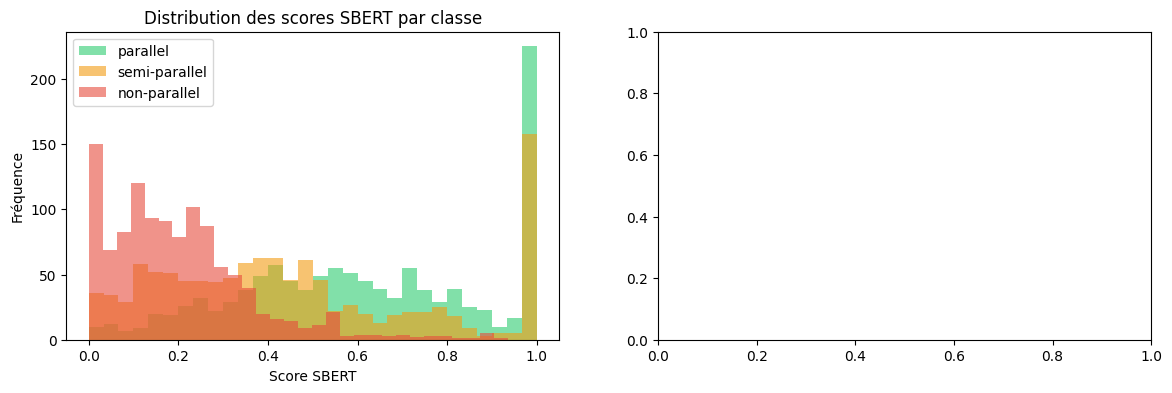

In [6]:
# SBERT score by class
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

colors = {"parallel": "#2ecc71", "semi-parallel": "#f39c12", "non-parallel": "#e74c3c"}

# Histograms
for cls, color in colors.items():
    subset = df[df["class"] == cls]["sbert_score"]
    axes[0].hist(subset, bins=30, alpha=0.6, color=color, label=cls)
axes[0].set_title("Distribution des scores SBERT par classe")
axes[0].set_xlabel("Score SBERT")
axes[0].set_ylabel("Fréquence")
axes[0].legend()

In [7]:
# Boxplots
df.boxplot(column="sbert_score", by="class", ax=axes[1],
           color=dict(boxes="blue", medians="red", whiskers="gray", caps="gray"))
axes[1].set_title("Boxplot SBERT par classe")
axes[1].set_xlabel("Classe")
axes[1].set_ylabel("Score SBERT")
plt.suptitle("")
plt.tight_layout()
plt.savefig("sbert_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure sauvegardée : sbert_distribution.png")

<Figure size 640x480 with 0 Axes>

Figure sauvegardée : sbert_distribution.png


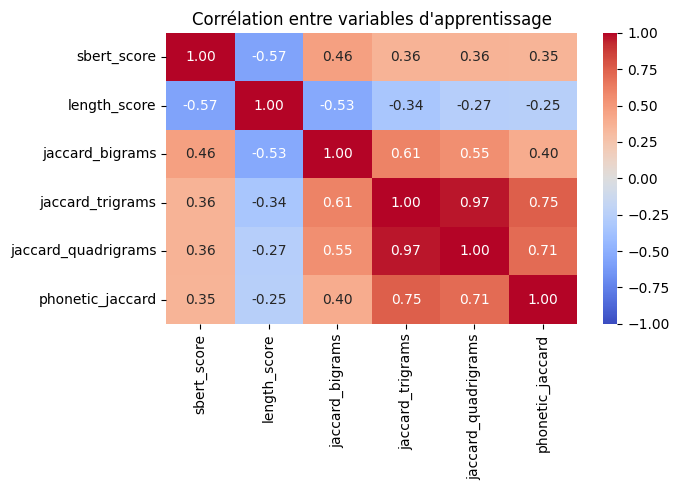

In [8]:
# Correlation matrix of variables
corr = df[FEATURE_COLS].corr()
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", ax=ax, vmin=-1, vmax=1)
ax.set_title("Corrélation entre variables d'apprentissage")
plt.tight_layout()
plt.savefig("feature_correlation.png", dpi=150, bbox_inches="tight")
plt.show()



---


## Préparation des données

In [9]:
X = df[FEATURE_COLS].values

# --- Binary target (1 for parallel and 0 for non-parallel) ---
y_bin = df["binary_class"].values

# --- Multiclass target ---
le = LabelEncoder()
y_mc = le.fit_transform(df["class"])          # 0=non-parallel, 1=parallel, 2=semi-parallel

# --- Train / Test ---
X_train, X_test, y_bin_train, y_bin_test, y_mc_train, y_mc_test = train_test_split(
    X, y_bin, y_mc,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y_mc
)

# --- Normalisation ---
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)
joblib.dump(scaler, SCALER_PATH)

print(f"\nEntraînement : {X_train_sc.shape[0]} paires")
print(f"Test         : {X_test_sc.shape[0]} paires")


Entraînement : 2748 paires
Test         : 687 paires




---


## Chargement des modèles

In [10]:
scaler    = joblib.load(SCALER_PATH)
model_bin = joblib.load(MODEL_BIN_PATH)
model_mc  = joblib.load(MODEL_MC_PATH)
mc_classes = model_mc.classes_

print(f"Scaler            : {SCALER_PATH}")
print(f"Binary model      : {MODEL_BIN_PATH}")
print(f"Multiclass model  : {MODEL_MC_PATH}")

Scaler            : ../data/models/scaler.joblib
Binary model      : ../data/models/logreg_binary.joblib
Multiclass model  : ../data/models/logreg_multiclass.joblib




---


## Évaluation

### Modèle binaire

=== Rapport de classification (binaire) ===
                          precision    recall  f1-score   support

           non-parallèle       0.63      0.90      0.74       229
parallèle/semi-parallèle       0.93      0.74      0.82       458

                accuracy                           0.79       687
               macro avg       0.78      0.82      0.78       687
            weighted avg       0.83      0.79      0.79       687



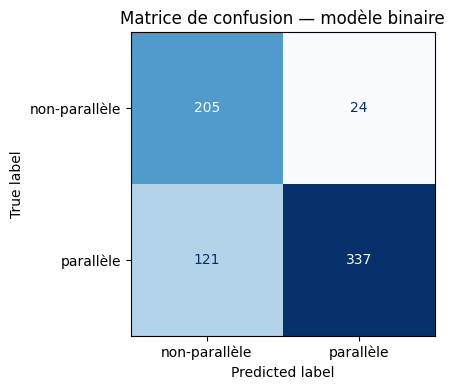

In [11]:
y_bin_pred  = logreg_bin.predict(X_test_sc)
y_bin_proba = logreg_bin.predict_proba(X_test_sc)[:, 1]

print("=== Rapport de classification (binaire) ===")
print(classification_report(y_bin_test, y_bin_pred,
                             target_names=["non-parallèle", "parallèle/semi-parallèle"]))

# Confusion matrix
fig, ax = plt.subplots(figsize=(5, 4))
cm = confusion_matrix(y_bin_test, y_bin_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=["non-parallèle", "parallèle"])
disp.plot(ax=ax, colorbar=False, cmap="Blues")
ax.set_title("Matrice de confusion — modèle binaire")
plt.tight_layout()
plt.savefig("confusion_binary.png", dpi=150, bbox_inches="tight")
plt.show()

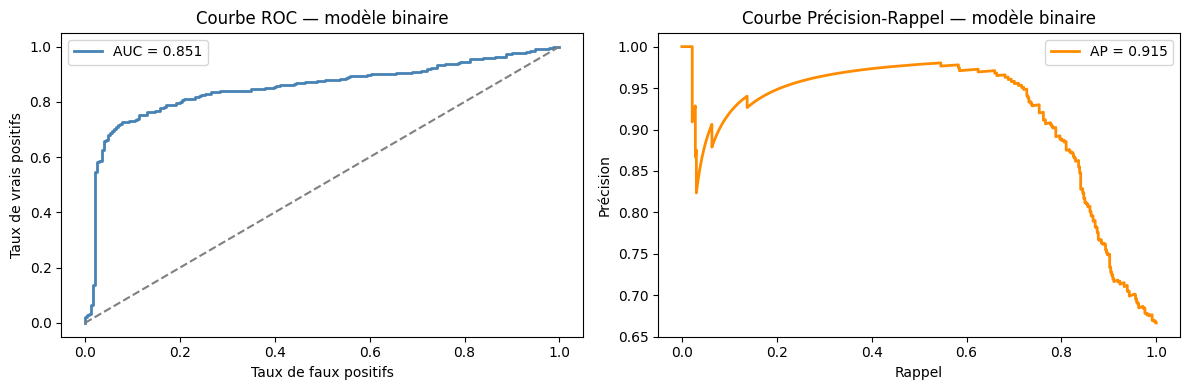

In [12]:
# ROC curve
fpr, tpr, _ = roc_curve(y_bin_test, y_bin_proba)
auc_score   = roc_auc_score(y_bin_test, y_bin_proba)

# Precision-recall curve
prec, rec, _ = precision_recall_curve(y_bin_test, y_bin_proba)
ap_score     = average_precision_score(y_bin_test, y_bin_proba)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(fpr, tpr, color="steelblue", lw=2, label=f"AUC = {auc_score:.3f}")
axes[0].plot([0, 1], [0, 1], "--", color="gray")
axes[0].set_xlabel("Taux de faux positifs")
axes[0].set_ylabel("Taux de vrais positifs")
axes[0].set_title("Courbe ROC — modèle binaire")
axes[0].legend()

axes[1].plot(rec, prec, color="darkorange", lw=2, label=f"AP = {ap_score:.3f}")
axes[1].set_xlabel("Rappel")
axes[1].set_ylabel("Précision")
axes[1].set_title("Courbe Précision-Rappel — modèle binaire")
axes[1].legend()

plt.tight_layout()
plt.savefig("roc_pr_binary.png", dpi=150, bbox_inches="tight")
plt.show()



---


### Modèle multiclasse

=== Rapport de classification (multiclasse) ===
               precision    recall  f1-score   support

 non-parallel       0.68      0.77      0.72       229
     parallel       0.77      0.93      0.84       229
semi-parallel       0.77      0.52      0.62       229

     accuracy                           0.74       687
    macro avg       0.74      0.74      0.73       687
 weighted avg       0.74      0.74      0.73       687



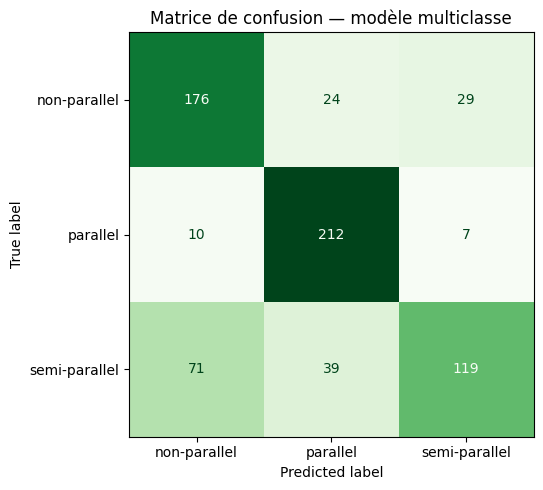

In [13]:
y_mc_pred = logreg_mc.predict(X_test_sc)

print("=== Rapport de classification (multiclasse) ===")
print(classification_report(y_mc_test, y_mc_pred, target_names=le.classes_))

# Confusion matrix
fig, ax = plt.subplots(figsize=(6, 5))
cm_mc = confusion_matrix(y_mc_test, y_mc_pred)
disp_mc = ConfusionMatrixDisplay(cm_mc, display_labels=le.classes_)
disp_mc.plot(ax=ax, colorbar=False, cmap="Greens")
ax.set_title("Matrice de confusion — modèle multiclasse")
plt.tight_layout()
plt.savefig("confusion_multiclass.png", dpi=150, bbox_inches="tight")
plt.show()



---


### Importance des variables

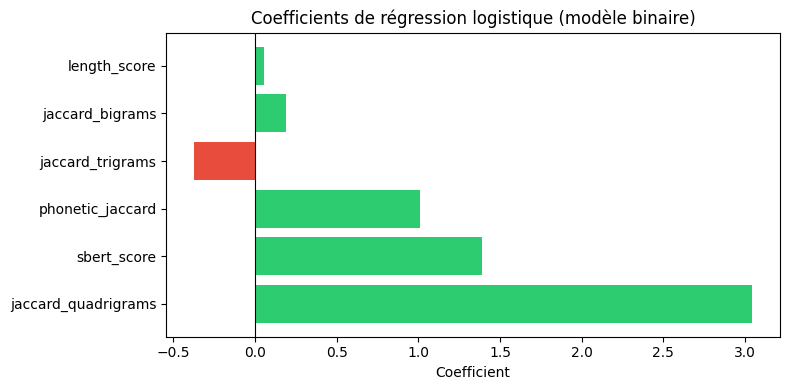

           variable  coefficient
jaccard_quadrigrams     3.043019
        sbert_score     1.390355
   phonetic_jaccard     1.008419
   jaccard_trigrams    -0.372198
    jaccard_bigrams     0.192637
       length_score     0.056683


In [14]:
# Binary model coefficients
coef_df = pd.DataFrame({
    "variable":   FEATURE_COLS,
    "coefficient": logreg_bin.coef_[0]
}).sort_values("coefficient", key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(8, 4))
colors_bar = ["#2ecc71" if c > 0 else "#e74c3c" for c in coef_df["coefficient"]]
ax.barh(coef_df["variable"], coef_df["coefficient"], color=colors_bar)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Coefficients de régression logistique (modèle binaire)")
ax.set_xlabel("Coefficient")
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()
print(coef_df.to_string(index=False))

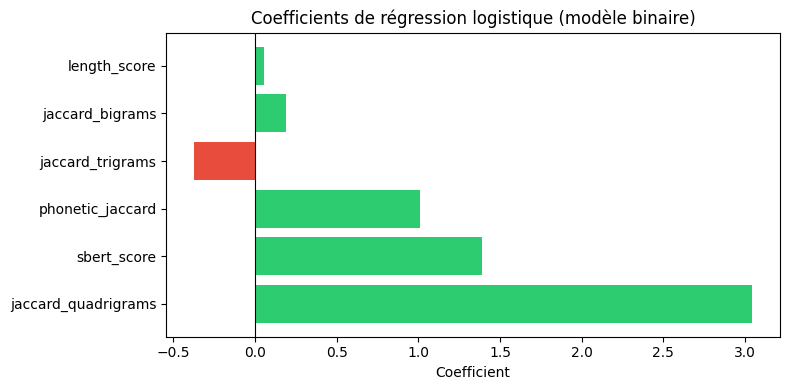

           variable  coefficient
jaccard_quadrigrams     3.043019
        sbert_score     1.390355
   phonetic_jaccard     1.008419
   jaccard_trigrams    -0.372198
    jaccard_bigrams     0.192637
       length_score     0.056683


In [15]:
coef_df = pd.DataFrame({
    "variable":   FEATURE_COLS,
    "coefficient": logreg_bin.coef_[0]
}).sort_values("coefficient", key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(8, 4))
colors_bar = ["#2ecc71" if c > 0 else "#e74c3c" for c in coef_df["coefficient"]]
ax.barh(coef_df["variable"], coef_df["coefficient"], color=colors_bar)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Coefficients de régression logistique (modèle binaire)")
ax.set_xlabel("Coefficient")
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()
print(coef_df.to_string(index=False))



---


### Résumé : Rappel, Précision et F1 — Modèles binaire et multiclasse

In [16]:
from sklearn.metrics import precision_score, recall_score, f1_score

# ---------------------------------------------------------------
# 1. Mod\u00e8le binaire \u2014 m\u00e9triques d\u00e9taill\u00e9es
# ---------------------------------------------------------------
print("=" * 60)
print("=== MOD\u00c8LE BINAIRE ===")
print("=" * 60)

classes_bin = ["non-parall\u00e8le", "parall\u00e8le/semi-parall\u00e8le"]

# average=None returns per-class metrics as arrays
prec_all = precision_score(y_bin_test, y_bin_pred, average=None)
rec_all  = recall_score(y_bin_test, y_bin_pred, average=None)
f1_all   = f1_score(y_bin_test, y_bin_pred, average=None)

for i, cls in enumerate(classes_bin):
    print(f"\n  Classe : {cls}")
    print(f"    Pr\u00e9cision : {prec_all[i]:.4f}")
    print(f"    Rappel    : {rec_all[i]:.4f}")
    print(f"    F1-Score  : {f1_all[i]:.4f}")

macro_prec  = precision_score(y_bin_test, y_bin_pred, average="macro")
macro_rec   = recall_score(y_bin_test, y_bin_pred, average="macro")
macro_f1    = f1_score(y_bin_test, y_bin_pred, average="macro")
weighted_prec  = precision_score(y_bin_test, y_bin_pred, average="weighted")
weighted_rec   = recall_score(y_bin_test, y_bin_pred, average="weighted")
weighted_f1    = f1_score(y_bin_test, y_bin_pred, average="weighted")

print(f"\n  Macro moyenne  : Pr\u00e9cision = {macro_prec:.4f} | Rappel = {macro_rec:.4f} | F1 = {macro_f1:.4f}")
print(f"  Weighted moyen : Pr\u00e9cision = {weighted_prec:.4f} | Rappel = {weighted_rec:.4f} | F1 = {weighted_f1:.4f}")

# ---------------------------------------------------------------
# 2. Mod\u00e8le multiclasse \u2014 m\u00e9triques d\u00e9taill\u00e9es
# ---------------------------------------------------------------
print("\n" + "=" * 60)
print("=== MOD\u00c8LE MULTICLASSE ===")
print("=" * 60)

classes_mc = le.classes_

prec_all = precision_score(y_mc_test, y_mc_pred, average=None)
rec_all  = recall_score(y_mc_test, y_mc_pred, average=None)
f1_all   = f1_score(y_mc_test, y_mc_pred, average=None)

for i, cls in enumerate(classes_mc):
    print(f"\n  Classe : {cls}")
    print(f"    Pr\u00e9cision : {prec_all[i]:.4f}")
    print(f"    Rappel    : {rec_all[i]:.4f}")
    print(f"    F1-Score  : {f1_all[i]:.4f}")

macro_prec  = precision_score(y_mc_test, y_mc_pred, average="macro")
macro_rec   = recall_score(y_mc_test, y_mc_pred, average="macro")
macro_f1    = f1_score(y_mc_test, y_mc_pred, average="macro")
weighted_prec  = precision_score(y_mc_test, y_mc_pred, average="weighted")
weighted_rec   = recall_score(y_mc_test, y_mc_pred, average="weighted")
weighted_f1    = f1_score(y_mc_test, y_mc_pred, average="weighted")

print(f"\n  Macro moyenne  : Pr\u00e9cision = {macro_prec:.4f} | Rappel = {macro_rec:.4f} | F1 = {macro_f1:.4f}")
print(f"  Weighted moyen : Pr\u00e9cision = {weighted_prec:.4f} | Rappel = {weighted_rec:.4f} | F1 = {weighted_f1:.4f}")


=== MODÈLE BINAIRE ===

  Classe : non-parallèle
    Précision : 0.6288
    Rappel    : 0.8952
    F1-Score  : 0.7387

  Classe : parallèle/semi-parallèle
    Précision : 0.9335
    Rappel    : 0.7358
    F1-Score  : 0.8230

  Macro moyenne  : Précision = 0.7812 | Rappel = 0.8155 | F1 = 0.7808
  Weighted moyen : Précision = 0.8320 | Rappel = 0.7889 | F1 = 0.7949

=== MODÈLE MULTICLASSE ===

  Classe : non-parallel
    Précision : 0.6848
    Rappel    : 0.7686
    F1-Score  : 0.7243

  Classe : parallel
    Précision : 0.7709
    Rappel    : 0.9258
    F1-Score  : 0.8413

  Classe : semi-parallel
    Précision : 0.7677
    Rappel    : 0.5197
    F1-Score  : 0.6198

  Macro moyenne  : Précision = 0.7412 | Rappel = 0.7380 | F1 = 0.7284
  Weighted moyen : Précision = 0.7412 | Rappel = 0.7380 | F1 = 0.7284


In [17]:
# ---------------------------------------------------------------
# Exemples : mieux et mal classés par classe
# ---------------------------------------------------------------
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split

FEATURE_COLS = ['sbert_score', 'length_score', 'jaccard_bigrams', 'jaccard_trigrams', 'jaccard_quadrigrams', 'phonetic_jaccard']

df_full = pd.read_csv(DATASET_PATH, encoding='utf-8-sig')
X_full = df_full[FEATURE_COLS].values
le_full = LabelEncoder()
y_full = le_full.fit_transform(df_full['class'])

idx_all = np.arange(len(df_full))
X_tr, X_te, y_tr, y_te, idx_tr, idx_te = train_test_split(
    X_full, y_full, idx_all, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y_full
)

scaler_full = StandardScaler()
X_tr_sc = scaler_full.fit_transform(X_tr)
X_te_sc = scaler_full.transform(X_te)

logreg_full = LogisticRegression(random_state=RANDOM_STATE, max_iter=1000, C=1.0)
logreg_full.fit(X_tr_sc, y_tr)
y_pred_full = logreg_full.predict(X_te_sc)
y_proba_full = logreg_full.predict_proba(X_te_sc)

classes_full = le_full.classes_

MIN_WORDS = 15

for cls_id, cls_name in enumerate(classes_full):
    correct_mask = (y_te == cls_id) & (y_pred_full == cls_id)
    incorrect_mask = (y_te == cls_id) & (y_pred_full != cls_id)

    correct_indices = np.where(correct_mask)[0]
    incorrect_indices = np.where(incorrect_mask)[0]

    print(f"\n{'='*70}")
    print(f"CLASSE: {cls_name} | Correct: {correct_indices.size} | Wrong: {incorrect_indices.size}")

    # Best: highest confidence on correct class among correct predictions (min 15 words)
    if correct_indices.size > 0:
        best_conf = 0
        best_idx = None
        for i in correct_indices:
            conf = y_proba_full[i, cls_id]
            row = df_full.iloc[idx_te[i]]
            fr_words = len(row['fr_sentence'].split())
            lr_words = len(row['lr_sentence'].split())
            if fr_words < MIN_WORDS or lr_words < MIN_WORDS:
                continue
            if conf > best_conf:
                best_conf = conf
                best_idx = i
        if best_idx is not None:
            row = df_full.iloc[idx_te[best_idx]]
            print(f"\n✓ MIEUX CLASSÉ (confiance: {best_conf:.2%}):")
            print(f"  [FR] {row['fr_sentence']}")
            print(f"  [LR] {row['lr_sentence']}")
            print(f"  Langue: {row['language_pair']}")
            print(f"  SBERT: {row['sbert_score']:.4f} | Quadrigram: {row['jaccard_quadrigrams']:.4f}")

    # Worst: most confidently wrong prediction (min 15 words)
    if incorrect_indices.size > 0:
        worst_conf = 0
        worst_idx = None
        for i in incorrect_indices:
            wrong_pred = y_pred_full[i]
            conf = y_proba_full[i, wrong_pred]
            row = df_full.iloc[idx_te[i]]
            fr_words = len(row['fr_sentence'].split())
            lr_words = len(row['lr_sentence'].split())
            if fr_words < MIN_WORDS or lr_words < MIN_WORDS:
                continue
            if conf > worst_conf:
                worst_conf = conf
                worst_idx = i
        if worst_idx is not None:
            row = df_full.iloc[idx_te[worst_idx]]
            wrong_pred_name = classes_full[y_pred_full[worst_idx]]
            print(f"\n✗ MAL CLASSÉ (en {wrong_pred_name}, confiance: {worst_conf:.2%}):")
            print(f"  [FR] {row['fr_sentence']}")
            print(f"  [LR] {row['lr_sentence']}")
            print(f"  Langue: {row['language_pair']}")
            print(f"  SBERT: {row['sbert_score']:.4f} | Quadrigram: {row['jaccard_quadrigrams']:.4f}")



CLASSE: non-parallel | Correct: 173 | Wrong: 56

✓ MIEUX CLASSÉ (confiance: 91.26%):
  [FR] Considérant que la reconnaissance de la dignité inhérente à tous les membres de la famille humaine et de leurs droits égaux et inaliénables constitue le fondement de la liberté, de la justice et de la paix dans le monde,
  [LR] Ella, allora si e astizzatu, e nun vulia più entra in casa.Lu Babbu allora esciutu fora e à cuminciatu a prigallu d'entra in casa.
  Langue: fr-co
  SBERT: 0.0000 | Quadrigram: 0.0035

✗ MAL CLASSÉ (en parallel, confiance: 90.20%):
  [FR] Les médecins l'ont montré : cette discrimination peut engendrer des problèmes psychologiques, voire des maladies organiques, comme des cancers de la face - le visage étant le siège de l'identité. (2)
  [LR] A la fin, estent dintrat en el mèmes, diguèt : quantes i a dins l’ostal de mon paire de vailets que an de pan mai lo que lor’n cal, et ieu aicí aganissi.
  Langue: fr-co
  SBERT: 0.2825 | Quadrigram: 0.0470

CLASSE: parallel | Correc



---


### Performances par langue régionale

In [18]:
from sklearn.metrics import f1_score, accuracy_score

# Get indexes from the test dataset
idx_test = df.index[len(X_train):len(X_train) + len(X_test)]

# Builds an annotated test DataFrame
_, df_test_raw = train_test_split(
    df, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y_mc
)
df_test_raw = df_test_raw.copy()
df_test_raw["pred_bin"]  = y_bin_pred
df_test_raw["true_bin"]  = y_bin_test
df_test_raw["pred_class"] = le.inverse_transform(y_mc_pred)

results_by_lang = []
for lang in ["co", "gsw", "oc"]:
    mask = df_test_raw["language_pair"] == lang
    if mask.sum() == 0:
        continue
    sub = df_test_raw[mask]
    f1  = f1_score(sub["true_bin"], sub["pred_bin"], zero_division=0)
    acc = accuracy_score(sub["true_bin"], sub["pred_bin"])
    results_by_lang.append({"Langue": lang, "N test": len(sub), "Accuracy": round(acc, 4), "F1": round(f1, 4)})

lang_df = pd.DataFrame(results_by_lang)
print("=== Performances par langue régionale (modèle binaire) ===")
print(lang_df.to_string(index=False))

=== Performances par langue régionale (modèle binaire) ===
Empty DataFrame
Columns: []
Index: []




---


## Sauvegarde et résumé

In [19]:
print("Fichiers sauvegardés :")
for f in [MODEL_BIN_PATH, MODEL_MC_PATH, SCALER_PATH]:
    print(f"\t+ {f}")

print("\nFigures sauvegardées :")
for f in ["sbert_distribution.png", "feature_correlation.png",
          "confusion_binary.png", "roc_pr_binary.png",
          "confusion_multiclass.png", "feature_importance.png"]:
    print(f"\t+ {f}")

Fichiers sauvegardés :
	+ ../data/models/logreg_binary.joblib
	+ ../data/models/logreg_multiclass.joblib
	+ ../data/models/scaler.joblib

Figures sauvegardées :
	+ sbert_distribution.png
	+ feature_correlation.png
	+ confusion_binary.png
	+ roc_pr_binary.png
	+ confusion_multiclass.png
	+ feature_importance.png




---


## Inférence sur de nouvelles paires

Cette section montre comment utiliser le modèle entraîné pour prédire si une nouvelle paire de phrases est parallèle, semi-parallèle ou non-parallèle.

Les fonctions de calcul des variables sont reprises du notebook de constitution du dataset.

In [20]:
try:
    import jellyfish
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "jellyfish", "-q"])
    import jellyfish

try:
    from sentence_transformers import SentenceTransformer
    from sklearn.metrics.pairwise import cosine_similarity as cos_sim
    _sbert_available = True
except ImportError:
    _sbert_available = False
    print("sentence-transformers non disponible — le score SBERT sera mis à 0.")

# -------------------------------------------------------
# Variable computing functions
# -------------------------------------------------------

def normalize(text):
    text = text.lower()
    text = unicodedata.normalize("NFD", text)
    text = "".join(c for c in text if unicodedata.category(c) != "Mn")
    return text.translate(str.maketrans("", "", string.punctuation)).strip()

def length_score(s1, s2):
    n1, n2  = len(s1.split()), len(s2.split())
    max_len = max(n1, n2)
    return 0.0 if max_len == 0 else abs(n1 - n2) / max_len

def char_ngrams(text, n):
    t = normalize(text)
    return set(t[i:i+n] for i in range(len(t) - n + 1))

def jaccard_index(a, b):
    if not a and not b:
        return 0.0
    return len(a & b) / len(a | b)

def jaccard_ngrams(s1, s2, n):
    return jaccard_index(char_ngrams(s1, n), char_ngrams(s2, n))

def metaphone_codes(text):
    codes = set()
    for word in normalize(text).split():
        try:
            code = jellyfish.metaphone(word)
            if code:
                codes.add(code)
        except Exception:
            pass
    return codes

def phonetic_jaccard(s1, s2):
    return jaccard_index(metaphone_codes(s1), metaphone_codes(s2))

# Loading SBERT model (once)
if _sbert_available:
    _sbert_model = SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2")

def compute_features(fr_sentence: str, lr_sentence: str) -> np.ndarray:
    """
    Computes the variables vector for a sentence pair.
    """
    if _sbert_available:
        emb1 = _sbert_model.encode([fr_sentence], convert_to_numpy=True)
        emb2 = _sbert_model.encode([lr_sentence], convert_to_numpy=True)
        sbert = float(max(0.0, cos_sim(emb1, emb2)[0][0]))
    else:
        sbert = 0.0

    return np.array([[
        sbert,
        length_score(fr_sentence, lr_sentence),
        jaccard_ngrams(fr_sentence, lr_sentence, 2),
        jaccard_ngrams(fr_sentence, lr_sentence, 3),
        jaccard_ngrams(fr_sentence, lr_sentence, 4),
        phonetic_jaccard(fr_sentence, lr_sentence),
    ]])


def predict_pair(fr_sentence: str, lr_sentence: str, mode: str = "binary") -> dict:
    """
    Predicts whether a sentence pair is parallel, semi-parallel or non-parallel.
    """
    # Loading models and scaler
    scaler_     = joblib.load(SCALER_PATH)
    model_bin_  = joblib.load(MODEL_BIN_PATH)
    model_mc_   = joblib.load(MODEL_MC_PATH)

    feats = compute_features(fr_sentence, lr_sentence)
    feats_sc = scaler_.transform(feats)

    if mode == "binary":
        pred  = model_bin_.predict(feats_sc)[0]
        proba = model_bin_.predict_proba(feats_sc)[0]
        label = "parallèle / semi-parallèle" if pred == 1 else "non-parallèle"
        conf  = proba[pred]
    else:
        pred  = model_mc_.predict(feats_sc)[0]
        proba = model_mc_.predict_proba(feats_sc)[0]
        label = le.inverse_transform([pred])[0]
        conf  = proba[pred]

    return {
        "prediction":  label,
        "confidence":  round(float(conf), 4),
        "features":    dict(zip(FEATURE_COLS, feats[0].tolist())),
    }


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 9325.99it/s]

In [21]:
# -------------------------------------------------------
# Inference exemple
# -------------------------------------------------------
test_pairs = [
    (
        "La bise et le soleil se disputaient, chacun assurant qu'il était le plus fort.",
        "La bisa e lo solelh se disputavan, cascun assegurant qu'èra lo mai fòrt.",   # occitan
        "Parallèle attendue"
    ),
    (
        "La bise et le soleil se disputaient, chacun assurant qu'il était le plus fort.",
        "La bisa e lo solelh se disputavan.",   # semi-parallel
        "Semi-parallèle attendue"
    ),
    (
        "Le gouvernement a annoncé de nouvelles mesures économiques.",
        "U ghjornu hè bellu è u mare hè calmu.",   # corsican, non parallel
        "Non-parallèle attendue"
    ),
    (
        "L'enseignement élémentaire est obligatoire.",
        "D'Grundschulbildig isch pflichtisch.",   # alsacian
        "Parallèle attendue"
    ),
]

print("=" * 70)
for fr, lr, expected in test_pairs:
    result_bin = predict_pair(fr, lr, mode="binary")
    result_mc  = predict_pair(fr, lr, mode="multiclass")
    print(f"[{expected}]")
    print(f"  FR : {fr[:70]}")
    print(f"  LR : {lr[:70]}")
    print(f"  Binaire     → {result_bin['prediction']}  (confiance : {result_bin['confidence']:.2%})")
    print(f"  Multiclasse → {result_mc['prediction']}  (confiance : {result_mc['confidence']:.2%})")
    print("-" * 70)

[Parallèle attendue]
  FR : La bise et le soleil se disputaient, chacun assurant qu'il était le pl
  LR : La bisa e lo solelh se disputavan, cascun assegurant qu'èra lo mai fòr
  Binaire     → parallèle / semi-parallèle  (confiance : 99.38%)
  Multiclasse → parallel  (confiance : 97.35%)
----------------------------------------------------------------------


[Semi-parallèle attendue]
  FR : La bise et le soleil se disputaient, chacun assurant qu'il était le pl
  LR : La bisa e lo solelh se disputavan.
  Binaire     → parallèle / semi-parallèle  (confiance : 96.18%)
  Multiclasse → semi-parallel  (confiance : 90.47%)
----------------------------------------------------------------------
[Non-parallèle attendue]
  FR : Le gouvernement a annoncé de nouvelles mesures économiques.
  LR : U ghjornu hè bellu è u mare hè calmu.
  Binaire     → non-parallèle  (confiance : 92.07%)
  Multiclasse → non-parallel  (confiance : 86.31%)
----------------------------------------------------------------------


[Parallèle attendue]
  FR : L'enseignement élémentaire est obligatoire.
  LR : D'Grundschulbildig isch pflichtisch.
  Binaire     → non-parallèle  (confiance : 86.88%)
  Multiclasse → non-parallel  (confiance : 89.04%)
----------------------------------------------------------------------


## Interprétation des coefficients du classifieur

Le classifieur utilisé est une **régression logistique** implémentée via `sklearn.linear_model.LogisticRegression`. Il a été entraîné sur l'ensemble `similarity_dataset.csv` contenant 3435 paires de phrases annotées selon trois classes : `parallèle`, `semi-parallèle` et `non-parallèle`. Les données sont divisées en un jeu d'entraînement (80 %) et un jeu de test (20 %) avec stratification, puis normalisées via un `StandardScaler` (mise à l'échelle centrée-réduite : chaque feature est centrée à moyenne nulle et réduite à écart-type unité). Cette normalisation est essentielle car les coefficients de régression logistique sont sensibles à l'échelle des variables : sans mise à l'échelle, une feature avec une grande amplitude dominerait artificiellement les autres.

L'entraînement proprement dit a été réalisé avec un paramètre de régularisation $C = 1.0$ (inverse de la force de régularisation L2) et un maximum de 1000 itérations. Deux modèles ont été sauvegardés : un **modèle binaire** (non-parallèle vs parallèle/semi-parallèle) et un **modèle multiclasse** (3 classes). Les modèles rechargés ici (`joblib.load`) permettent d'extraire les coefficients appris.

Chaque coefficient $w_j$ d'une feature $x_j$ représente l'impact de cette feature sur le **log-odds** (logarithme du rapport de cotes) de la classe cible. Plus précisément, pour le modèle binaire, la prédiction s'effectue selon :

$$
\log\left(\frac{P(y=1 \mid \mathbf{x})}{P(y=0 \mid \mathbf{x})}\right) = w_0 + w_1 x_1 + w_2 x_2 + \cdots + w_6 x_6
$$

Un coefficient **positif** signifie qu'une augmentation de la feature augmente la probabilité d'appartenir à la classe positive (parallèle/semi-parallèle). À l'inverse, un coefficient **négatif** indique que la feature est associée à la classe négative (non-parallèle). L'**odds ratio** $e^{w_j}$ permet d'interpréter l'effet de la feature dans l'espace probabiliste : par exemple, un odds ratio de 3 signifie qu'une augmentation d'un écart-type de la feature multiplie les chances (odds) d'être dans la classe positive par 3. Ainsi, l'odds ratio est plus intuitif que le coefficient brut pour communiquer l'ampleur de l'effet d'une feature.

Le tableau ci-dessous présente les coefficients et les odds ratios pour le modèle binaire, suivis des coefficients et odds ratios par classe pour le modèle multiclasse. Les graphiques associés visualisent ces coefficients par feature.

=== MODÈLE BINAIRE ===
Classe 1 = parallèle/semi-parallèle
           variable  coefficient  odds_ratio
jaccard_quadrigrams     3.043019   20.968449
        sbert_score     1.390355    4.016275
   phonetic_jaccard     1.008419    2.741264
   jaccard_trigrams    -0.372198    0.689218
    jaccard_bigrams     0.192637    1.212443
       length_score     0.056683    1.058320


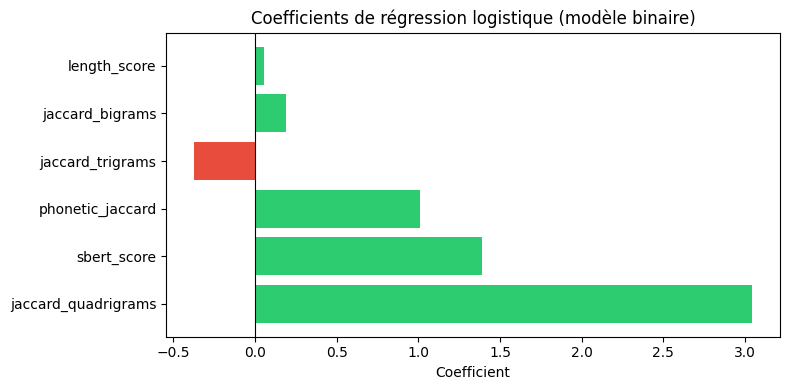


=== MODÈLE MULTICLASSE (3 classes) ===
Classes : ['non-parallel', 'parallel', 'semi-parallel']
 coef_non-parallel  or_non-parallel  coef_parallel  or_parallel  coef_semi-parallel  or_semi-parallel            variable
         -0.843735         0.430101       0.114041     1.120798            0.729694          2.074446         sbert_score
          0.825010         2.281904      -2.512841     0.081038            1.687831          5.407740        length_score
         -0.249499         0.779191       0.079618     1.082873            0.169881          1.185164     jaccard_bigrams
         -0.005087         0.994926       2.204725     9.067754           -2.199638          0.110843    jaccard_trigrams
         -1.939674         0.143751      -0.727931     0.482907            2.667605         14.405429 jaccard_quadrigrams
         -1.058562         0.346955       0.379326     1.461300            0.679235          1.972369    phonetic_jaccard


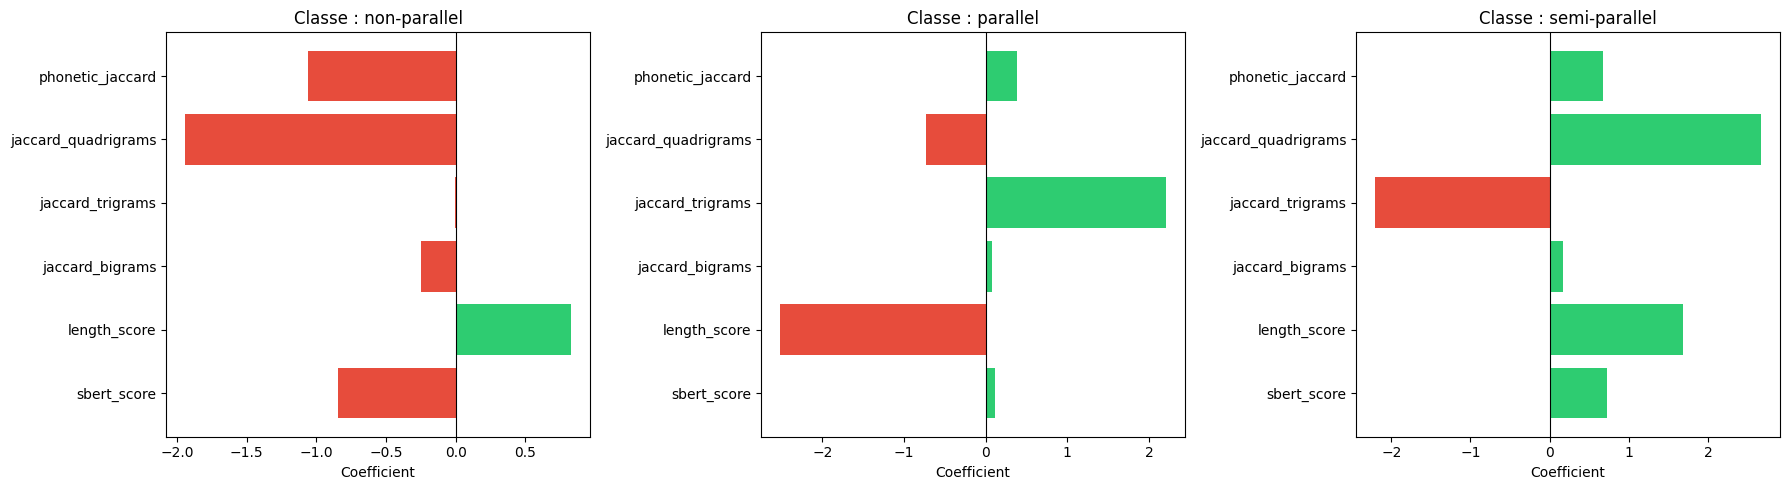

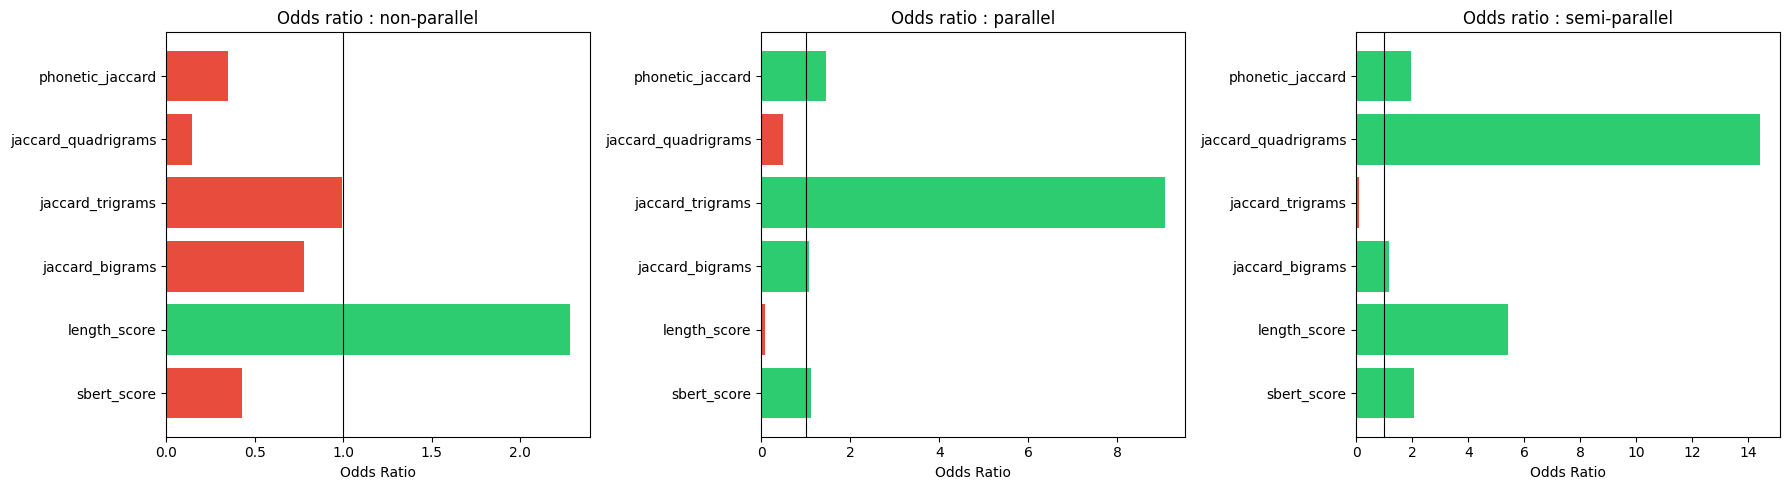


=== RÉSUMÉ DES ODDS RATIOS ===
           variable  or_non-parallel  or_parallel  or_semi-parallel
        sbert_score         0.430101     1.120798          2.074446
       length_score         2.281904     0.081038          5.407740
    jaccard_bigrams         0.779191     1.082873          1.185164
   jaccard_trigrams         0.994926     9.067754          0.110843
jaccard_quadrigrams         0.143751     0.482907         14.405429
   phonetic_jaccard         0.346955     1.461300          1.972369


In [ ]:
# ---------------------------------------------------------------
# Analyse détaillée des coefficients
# ---------------------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt

# Recharger les modèles

# --- Modèle binaire ---
coef_df_bin = pd.DataFrame({
    "variable": FEATURE_COLS,
    "coefficient": logreg_bin.coef_[0],
    "odds_ratio": np.exp(logreg_bin.coef_[0])
}).sort_values("coefficient", key=abs, ascending=False)

print("=== MODÈLE BINAIRE ===")
print("Classe 1 = parallèle/semi-parallèle")
print(coef_df_bin.to_string(index=False))

# Graphique binaire
fig, ax = plt.subplots(figsize=(8, 4))
colors_bar = ["#2ecc71" if c > 0 else "#e74c3c" for c in coef_df_bin["coefficient"]]
ax.barh(coef_df_bin["variable"], coef_df_bin["coefficient"], color=colors_bar)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Coefficients de régression logistique (modèle binaire)")
ax.set_xlabel("Coefficient")
plt.tight_layout()
plt.savefig("feature_importance_binary.png", dpi=150, bbox_inches="tight")
plt.show()

# --- Modèle multiclasse ---
classes_mc = le.classes_
print(f"\n=== MODÈLE MULTICLASSE ({len(classes_mc)} classes) ===")
print(f"Classes : {list(classes_mc)}")

coef_df_mc = pd.DataFrame()
for i, cls in enumerate(classes_mc):
    coef_df_mc[f"coef_{cls}"] = logreg_mc.coef_[i]
    coef_df_mc[f"or_{cls}"] = np.exp(logreg_mc.coef_[i])
coef_df_mc["variable"] = FEATURE_COLS

print(coef_df_mc.to_string(index=False))

# Graphique multiclasse - coefficients
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, cls in enumerate(classes_mc):
    data = pd.DataFrame({"variable": FEATURE_COLS, "coefficient": logreg_mc.coef_[i]})
    colors = ["#2ecc71" if c > 0 else "#e74c3c" for c in data["coefficient"]]
    axes[i].barh(data["variable"], data["coefficient"], color=colors)
    axes[i].axvline(0, color="black", linewidth=0.8)
    axes[i].set_title(f"Classe : {cls}")
    axes[i].set_xlabel("Coefficient")
plt.tight_layout()
plt.savefig("feature_importance_multiclass.png", dpi=150, bbox_inches="tight")
plt.show()

# Graphique multiclasse - odds ratios
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, cls in enumerate(classes_mc):
    data = pd.DataFrame({"variable": FEATURE_COLS, "odds_ratio": np.exp(logreg_mc.coef_[i])})
    colors = ["#2ecc71" if v > 1 else "#e74c3c" for v in data["odds_ratio"]]
    axes[i].barh(data["variable"], data["odds_ratio"], color=colors)
    axes[i].axvline(1, color="black", linewidth=0.8)
    axes[i].set_title(f"Odds ratio : {cls}")
    axes[i].set_xlabel("Odds Ratio")
plt.tight_layout()
plt.savefig("feature_importance_multiclass_or.png", dpi=150, bbox_inches="tight")
plt.show()

# --- Tableau résumé ---
print("\n=== RÉSUMÉ DES ODDS RATIOS ===")
or_df = pd.DataFrame({"variable": FEATURE_COLS})
for i, cls in enumerate(classes_mc):
    or_df[f"or_{cls}"] = np.exp(logreg_mc.coef_[i])
print(or_df.to_string(index=False))


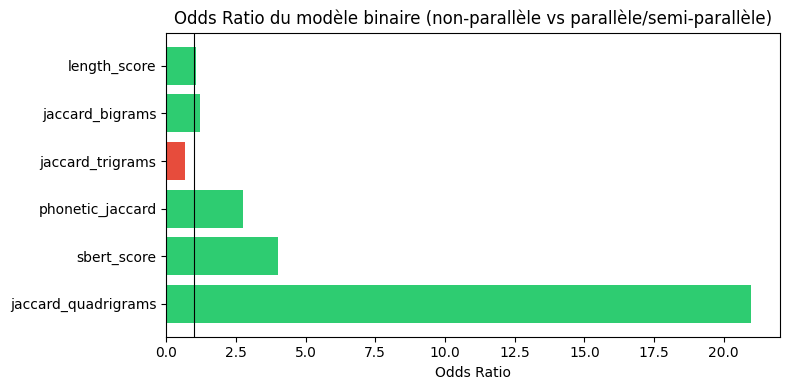

Graphique Odds Ratio (modèle binaire) sauvegardé : feature_importance_binary_or.png


In [ ]:
# ── Graphique Odds Ratio du modèle binaire ───────────────────────────────
# Les odds ratios sont plus intuitifs que les coefficients bruts :
# OR > 1 => la feature augmente les chances d'être dans la classe positive
# OR < 1 => la feature diminue les chances d'être dans la classe positive
# OR = 1 => la feature n'a aucun effet

fig, ax = plt.subplots(figsize=(8, 4))

# Odds ratios pour le modèle binaire
or_bin = np.exp(logreg_bin.coef_[0])
colors_or = ['#2ecc71' if o > 1 else '#e74c3c' for o in or_bin]

# Trier par coefficient absolu pour avoir le même ordre que le graphe de coefficients
coef_df_or = pd.DataFrame({
    'variable': FEATURE_COLS,
    'odds_ratio': or_bin,
    'coefficient': logreg_bin.coef_[0]
}).sort_values('coefficient', key=abs, ascending=False)

ax.barh(coef_df_or['variable'], coef_df_or['odds_ratio'], color=colors_or)
ax.axvline(1, color='black', linewidth=0.8)
ax.set_title('Odds Ratio du modèle binaire (non-parallèle vs parallèle/semi-parallèle)')
ax.set_xlabel('Odds Ratio')
plt.tight_layout()
fig.savefig('feature_importance_binary_or.png', dpi=150, bbox_inches='tight')
plt.show()
print('Graphique Odds Ratio (modèle binaire) sauvegardé : feature_importance_binary_or.png')
